# NLP Training - CitizenCare
Model klasifikasi tingkat kerusakan infrastruktur menggunakan IndoBERT

## DEPENDENCIES

In [10]:
!pip install -q tensorflow tf-keras transformers==4.35.2 scikit-learn pandas numpy matplotlib seaborn joblib

In [11]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from transformers import AutoTokenizer, TFAutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    TensorBoard
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", tf.config.list_physical_devices("GPU"))

TensorFlow Version : 2.20.0
GPU Available      : []


## DATASET

In [12]:
url = "https://docs.google.com/spreadsheets/d/12kN1aoxen_WHUah5iGkBDZapACwyCkW0H_e-4t5Enoo/export?format=csv"

df = pd.read_csv(url)

print(df.info())
print("\nSample data:")
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12024 entries, 0 to 12023
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   deskripsi_laporan    12024 non-null  object
 1   deskripsi_cleaned    12024 non-null  object
 2   jenis_infrastruktur  12024 non-null  object
 3   kota_administrasi    12024 non-null  object
 4   tingkat_kerusakan    12024 non-null  object
 5   label_encoded        12024 non-null  int64 
 6   char_length          12024 non-null  int64 
 7   word_count           12024 non-null  int64 
 8   has_urgency_keyword  12024 non-null  int64 
 9   augmented            12024 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 939.5+ KB
None

Sample data:
                                   deskripsi_laporan  \
0  ada celah kecil di aspal jalan dekat jalan ahm...   
1  trotoar jalan ahmad yani perlu pengecatan ulan...   
2  lampu penerangan di jalan tb simatupang kurang...   
3  ubin 

## DATA PIPELINE

In [13]:
TEXT_COLUMN  = "deskripsi_cleaned"
LABEL_COLUMN = "label_encoded"

# FIX: label_encoded = 0→ringan, 1→sedang, 2→berat (bukan jenis infrastruktur)
LABEL_MAPPING = {
    0: "ringan",
    1: "sedang",
    2: "berat"
}

MODEL_NAME      = "indobenchmark/indobert-base-p1"
MAX_LEN         = 128
BATCH_SIZE      = 4
PREFETCH_BUFFER = 1

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model Name     :", MODEL_NAME)
print("Max Length     :", MAX_LEN)
print("Batch Size     :", BATCH_SIZE)
print("Label Mapping  :", LABEL_MAPPING)
print("Tokenizer Loaded")

Model Name     : indobenchmark/indobert-base-p1
Max Length     : 128
Batch Size     : 4
Label Mapping  : {0: 'ringan', 1: 'sedang', 2: 'berat'}
Tokenizer Loaded


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## PREPROCESSING

Text Shape    : (12024,)
Numeric Shape : (12024, 4)
Label Shape   : (12024,)

Distribusi label:
label_encoded
ringan    4008
sedang    4008
berat     4008
Name: count, dtype: int64


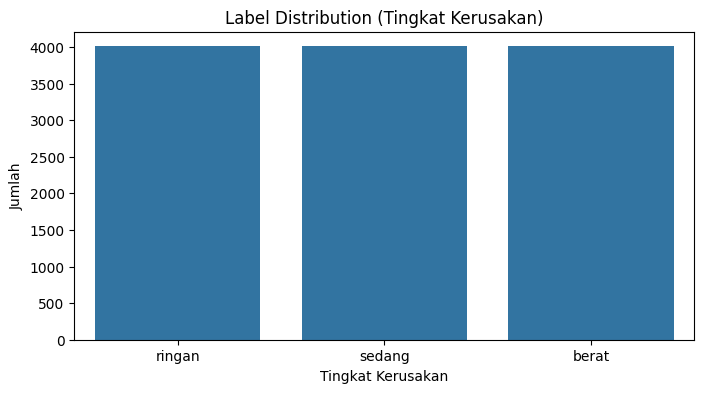

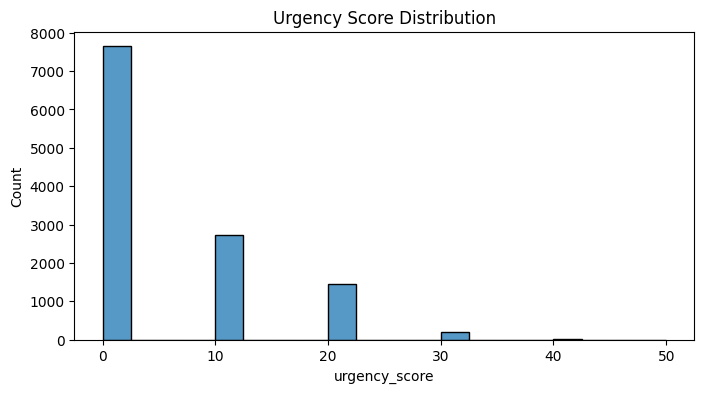

In [14]:
X_text = df[TEXT_COLUMN].astype(str)
y      = df[LABEL_COLUMN]

# Keyword urgency untuk fitur numerik tambahan
URGENCY_KEYWORDS = [
    "darurat", "parah", "besar", "bahaya", "rusak berat",
    "banjir besar", "ambles", "putus", "kebakaran", "longsor",
    "fatal", "urgent", "tolong", "segera", "terendam",
    "gawat", "macet parah", "membahayakan", "korban", "retak besar"
]

def calculate_urgency_score(text):
    text  = str(text).lower()
    score = 0
    for keyword in URGENCY_KEYWORDS:
        if keyword in text:
            score += 10
    if len(text.split()) > 20:
        score += 10
    return min(score, 100)

# FIX: uncomment — kolom urgency_score HARUS dibuat sebelum dipakai sebagai fitur
df["urgency_score"] = df[TEXT_COLUMN].apply(calculate_urgency_score)

# severity_target: mapping dari tingkat_kerusakan (label ground truth untuk regression head)
damage_map = {"ringan": 0.2, "sedang": 0.5, "berat": 1.0}
df["severity_target"] = df["tingkat_kerusakan"].str.lower().map(damage_map)

# FIX: NUMERIC_COLUMNS harus konsisten antara training dan inferensi
# Kolom yang benar-benar ada di dataset + urgency_score yang baru dibuat
NUMERIC_COLUMNS = [
    "char_length",
    "word_count",
    "has_urgency_keyword",
    "urgency_score"
]

X_numeric = df[NUMERIC_COLUMNS]

scaler = MinMaxScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric).astype("float32")

print("Text Shape    :", X_text.shape)
print("Numeric Shape :", X_numeric_scaled.shape)
print("Label Shape   :", y.shape)
print("\nDistribusi label:")
print(df[LABEL_COLUMN].map(LABEL_MAPPING).value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(x=df[LABEL_COLUMN].map(LABEL_MAPPING), order=["ringan","sedang","berat"])
plt.title("Label Distribution (Tingkat Kerusakan)")
plt.xlabel("Tingkat Kerusakan")
plt.ylabel("Jumlah")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df["urgency_score"], bins=20)
plt.title("Urgency Score Distribution")
plt.show()

## SPLIT DATA

In [15]:
y               = np.array(df[LABEL_COLUMN])
severity_target = np.array(df["severity_target"]).astype("float32")

# Split 80% train — 10% val — 10% test
(
    X_text_train, X_text_temp,
    X_num_train,  X_num_temp,
    y_train,      y_temp,
    severity_train, severity_temp
) = train_test_split(
    X_text, X_numeric_scaled, y, severity_target,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

(
    X_text_val,  X_text_test,
    X_num_val,   X_num_test,
    y_val,       y_test,
    severity_val, severity_test
) = train_test_split(
    X_text_temp, X_num_temp, y_temp, severity_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print("Train Size :", len(X_text_train))
print("Val Size   :", len(X_text_val))
print("Test Size  :", len(X_text_test))

print("\nSample teks    :", X_text_train.iloc[0])
print("Label kelas    :", LABEL_MAPPING[y_train[0]])
print("Severity target:", severity_train[0])

Train Size : 9619
Val Size   : 1202
Test Size  : 1203

Sample teks    : kabel fiber di jalan tb simatupang sedikit kendur perlu dikencangkan
Label kelas    : ringan
Severity target: 0.2


In [16]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN    = 128
BATCH_SIZE = 16

# ============================================================
# Dataset Class — pakai array hasil split langsung
# ============================================================
class BugReportDataset(Dataset):
    def __init__(self, texts, numerics, labels, severities, tokenizer, max_len):
        self.texts      = texts        # X_text_train / val / test (Series/array)
        self.numerics   = numerics     # X_num_train  / val / test (numpy array)
        self.labels     = labels       # y_train      / val / test (numpy array)
        self.severities = severities   # severity_train / val / test (numpy array)
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx] if hasattr(self.texts, "iloc") else self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length     = self.max_len,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )

        return {
            "input_ids"     : encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "numeric_input" : torch.tensor(self.numerics[idx], dtype=torch.float32),
            "labels"        : torch.tensor(self.labels[idx], dtype=torch.long),
            "severity"      : torch.tensor(self.severities[idx], dtype=torch.float32),
        }

# ============================================================
# Buat Dataset & DataLoader dari variabel split-mu
# ============================================================
train_dataset = BugReportDataset(X_text_train, X_num_train, y_train, severity_train, tokenizer, MAX_LEN)
val_dataset   = BugReportDataset(X_text_val,   X_num_val,   y_val,   severity_val,   tokenizer, MAX_LEN)
test_dataset  = BugReportDataset(X_text_test,  X_num_test,  y_test,  severity_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train : {len(train_dataset)} samples → {len(train_loader)} batches")
print(f"Val   : {len(val_dataset)} samples → {len(val_loader)} batches")
print(f"Test  : {len(test_dataset)} samples → {len(test_loader)} batches")

Train : 9619 samples → 602 batches
Val   : 1202 samples → 76 batches
Test  : 1203 samples → 76 batches


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## BUILD DATASET & MODEL

In [17]:
!pip install torch

In [18]:
import torch
import torch.nn as nn
from transformers import AutoModel

MODEL_NAME = "indobenchmark/indobert-base-p1"

# ✅ Custom Attention Layer (equivalent dengan versi TF-mu)
class AttentionLayer(nn.Module):
    def __init__(self, units):
        super().__init__()
        self.W = nn.Linear(units, units)   # equivalent: tf.keras.layers.Dense(units)
        self.V = nn.Linear(units, 1)       # equivalent: tf.keras.layers.Dense(1)

    def forward(self, features):
        score             = torch.tanh(self.W(features))          # tf.nn.tanh(self.W(features))
        attention_weights = torch.softmax(self.V(score), dim=1)   # tf.nn.softmax(..., axis=1)
        context_vector    = attention_weights * features           # element-wise multiply
        return context_vector.sum(dim=1)                          # tf.reduce_sum(..., axis=1)


class IndoBERTClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # BERT branch (frozen)
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        for param in self.bert.parameters():
            param.requires_grad = False

        bert_hidden = self.bert.config.hidden_size  # 768

        # ✅ BERT branch (sama persis struktur TF-mu)
        self.attention = AttentionLayer(bert_hidden)  # AttentionLayer(128) → pakai bert_hidden
        self.dropout1  = nn.Dropout(0.4)
        self.dense1    = nn.Linear(bert_hidden, 128)
        self.bn1       = nn.BatchNorm1d(128)
        self.dropout2  = nn.Dropout(0.4)

        # ✅ Numeric branch (sama persis)
        self.num_dense1 = nn.Linear(4, 64)
        self.num_drop   = nn.Dropout(0.3)
        self.num_dense2 = nn.Linear(64, 32)

        # ✅ Combined branch (sama persis)
        self.combined1 = nn.Linear(128 + 32, 128)
        self.bn2       = nn.BatchNorm1d(128)
        self.dropout3  = nn.Dropout(0.4)
        self.combined2 = nn.Linear(128, 64)

        # ✅ Output heads (sama persis)
        self.class_output    = nn.Linear(64, num_classes)  # softmax di loss, bukan di sini
        self.severity_output = nn.Linear(64, 1)            # sigmoid

    def forward(self, input_ids, attention_mask, numeric_input):
        # BERT branch
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = self.attention(bert_out.last_hidden_state)
        x = self.dropout1(x)
        x = torch.relu(self.dense1(x))
        x = self.bn1(x)
        x = self.dropout2(x)

        # Numeric branch
        num = torch.relu(self.num_dense1(numeric_input))
        num = self.num_drop(num)
        num = torch.relu(self.num_dense2(num))

        # Combined
        combined = torch.cat([x, num], dim=1)
        combined = torch.relu(self.combined1(combined))
        combined = self.bn2(combined)
        combined = self.dropout3(combined)
        combined = torch.relu(self.combined2(combined))

        # Output
        class_out    = self.class_output(combined)                    # logits (raw)
        severity_out = torch.sigmoid(self.severity_output(combined))  # 0-1

        return class_out, severity_out

In [19]:
!pip install tensorflow==2.13.0 keras==2.13.1 transformers==4.35.2

ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.13.0


In [20]:
# # Custom Attention Layer
# @tf.keras.utils.register_keras_serializable()
# class AttentionLayer(tf.keras.layers.Layer):
#     def __init__(self, units, **kwargs):
#         super().__init__(**kwargs)
#         self.units = units
#         self.W = tf.keras.layers.Dense(units)
#         self.V = tf.keras.layers.Dense(1)

#     def call(self, features):
#         score            = tf.nn.tanh(self.W(features))
#         attention_weights = tf.nn.softmax(self.V(score), axis=1)
#         context_vector   = attention_weights * features
#         return tf.reduce_sum(context_vector, axis=1)

#     def get_config(self):
#         config = super().get_config()
#         config.update({"units": self.units})
#         return config

# # Load IndoBERT (frozen sebagai feature extractor)
# bert_model = TFAutoModel.from_pretrained(MODEL_NAME)
# bert_model.trainable = False

# # Input layers
# input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32,   name="input_ids")
# attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32,   name="attention_mask")
# numeric_input = tf.keras.Input(shape=(4,),        dtype=tf.float32, name="numeric_input")

# # BERT branch
# bert_output     = bert_model(input_ids=input_ids, attention_mask=attention_mask)
# sequence_output = bert_output.last_hidden_state

# x = AttentionLayer(128)(sequence_output)
# x = tf.keras.layers.Dropout(0.4)(x)
# x = tf.keras.layers.Dense(128, activation="relu")(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Dropout(0.4)(x)

# # Numeric branch
# num_branch = tf.keras.layers.Dense(64, activation="relu")(numeric_input)
# num_branch = tf.keras.layers.Dropout(0.3)(num_branch)
# num_branch = tf.keras.layers.Dense(32, activation="relu")(num_branch)

# # Gabungkan
# combined = tf.keras.layers.concatenate([x, num_branch])
# combined = tf.keras.layers.Dense(128, activation="relu")(combined)
# combined = tf.keras.layers.BatchNormalization()(combined)
# combined = tf.keras.layers.Dropout(0.4)(combined)
# combined = tf.keras.layers.Dense(64, activation="relu")(combined)

# # FIX: NUM_CLASSES = 3 (ringan/sedang/berat), bukan 5
NUM_CLASSES = len(LABEL_MAPPING)  # = 3

# class_output = tf.keras.layers.Dense(
#     NUM_CLASSES, activation="softmax", name="class_output"
# )(combined)

# severity_output = tf.keras.layers.Dense(
#     1, activation="sigmoid", name="severity_output"
# )(combined)

# model = tf.keras.Model(
#     inputs=[input_ids, attention_mask, numeric_input],
#     outputs=[class_output, severity_output]
# )

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
#     loss={
#         "class_output"   : "sparse_categorical_crossentropy",
#         "severity_output": "mae"
#     },
#     loss_weights={
#         "class_output"   : 1.0,
#         "severity_output": 0.3
#     },
#     metrics={
#         "class_output"   : ["accuracy"],
#         "severity_output": ["mae"]
#     }
# )

# model.summary()

## TRAINING

In [21]:
import os
import datetime
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter

os.makedirs("models", exist_ok=True)
os.makedirs("logs",   exist_ok=True)

CHECKPOINT_PATH = "models/checkpoint_resume.pt"
EPOCHS          = 15
PATIENCE        = 4
TARGET_VAL_ACC  = 0.90  # ✅ Early stop jika val_acc >= 90%

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = IndoBERTClassifier(num_classes=NUM_CLASSES).to(device)

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    # verbose=True
)

# ============================================================
# ✅ Resume Training — load checkpoint kalau ada
# ============================================================
start_epoch      = 0
best_val_acc     = 0.0
patience_counter = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"🔄 Checkpoint ditemukan, melanjutkan training...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])

    start_epoch      = checkpoint["epoch"] + 1
    best_val_acc     = checkpoint["best_val_acc"]
    patience_counter = checkpoint["patience_counter"]

    print(f"Lanjut dari epoch {start_epoch + 1}")
    print(f"↪ Best val_acc sebelumnya : {best_val_acc:.4f}")
else:
    print("🚀 Memulai training dari awal...")


# ============================================================
# Helper: save checkpoint lengkap
# ============================================================
def save_checkpoint(epoch, best_val_acc, patience_counter):
    torch.save({
        "epoch"           : epoch,
        "model_state"     : model.state_dict(),
        "optimizer_state" : optimizer.state_dict(),
        "scheduler_state" : scheduler.state_dict(),
        "best_val_acc"    : best_val_acc,
        "patience_counter": patience_counter,
    }, CHECKPOINT_PATH)


# ============================================================
# Helper: satu epoch train / eval
# ============================================================
def run_epoch(loader, training=True):
    model.train() if training else model.eval()

    total_loss, total_mae = 0, 0
    correct, total        = 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            numeric_input  = batch["numeric_input"].to(device)
            labels         = batch["labels"].to(device)
            severity       = batch["severity"].float().to(device)

            class_out, severity_out = model(input_ids, attention_mask, numeric_input)

            loss_class    = F.cross_entropy(class_out, labels)
            loss_severity = F.l1_loss(severity_out.squeeze(), severity)
            loss          = loss_class * 1.0 + loss_severity * 0.3

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_mae  += loss_severity.item()

            preds    = class_out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    n = len(loader)
    return {
        "loss"    : total_loss / n,
        "accuracy": correct / total,
        "mae"     : total_mae / n,
    }


# ============================================================
# Helper: print summary per epoch
# ============================================================
def print_epoch_summary(epoch, train_m, val_m):
    print("\n===================================")
    print(f"Epoch {epoch + 1} Completed")
    print("===================================")
    print(f"Train Accuracy : {train_m['accuracy']:.4f}")
    print(f"Val Accuracy   : {val_m['accuracy']:.4f}")
    print(f"Train MAE      : {train_m['mae']:.4f}")
    print(f"Val MAE        : {val_m['mae']:.4f}")


# ============================================================
# Training Loop utama
# ============================================================
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
writer  = SummaryWriter(log_dir=log_dir)

for epoch in range(start_epoch, EPOCHS):
    train_metrics = run_epoch(train_loader, training=True)
    val_metrics   = run_epoch(val_loader,   training=False)

    print_epoch_summary(epoch, train_metrics, val_metrics)

    # TensorBoard
    writer.add_scalars("Accuracy", {"train": train_metrics["accuracy"], "val": val_metrics["accuracy"]}, epoch)
    writer.add_scalars("MAE",      {"train": train_metrics["mae"],      "val": val_metrics["mae"]},      epoch)
    writer.add_scalars("Loss",     {"train": train_metrics["loss"],     "val": val_metrics["loss"]},     epoch)

    # ReduceLROnPlateau
    scheduler.step(val_metrics["accuracy"])

    # ModelCheckpoint — save best model
    if val_metrics["accuracy"] > best_val_acc:
        best_val_acc     = val_metrics["accuracy"]
        patience_counter = 0
        torch.save(model.state_dict(), "models/best_indobert_model.pt")
        print(f"  ✅ Best model saved (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")

    # ✅ Save checkpoint resume setiap epoch
    save_checkpoint(epoch, best_val_acc, patience_counter)
    print(f"  💾 Checkpoint disimpan (epoch {epoch + 1})")

    # ✅ Early stop jika val_acc >= 90%
    if val_metrics["accuracy"] >= TARGET_VAL_ACC:
        print(f"\n🎯 Target tercapai! Val accuracy {val_metrics['accuracy']:.4f} >= {TARGET_VAL_ACC}")
        print(f"   Training dihentikan di epoch {epoch + 1}")
        break

    # Early stop jika tidak ada improvement (patience)
    if patience_counter >= PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch + 1}")
        break

writer.close()

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

🚀 Memulai training dari awal...

Epoch 1 Completed
Train Accuracy : 0.4041
Val Accuracy   : 0.6306
Train MAE      : 0.2816
Val MAE        : 0.2711
  ✅ Best model saved (val_acc=0.6306)
  💾 Checkpoint disimpan (epoch 1)

Epoch 2 Completed
Train Accuracy : 0.5862
Val Accuracy   : 0.7438
Train MAE      : 0.2704
Val MAE        : 0.2583
  ✅ Best model saved (val_acc=0.7438)
  💾 Checkpoint disimpan (epoch 2)

Epoch 3 Completed
Train Accuracy : 0.6973
Val Accuracy   : 0.8270
Train MAE      : 0.2421
Val MAE        : 0.2071
  ✅ Best model saved (val_acc=0.8270)
  💾 Checkpoint disimpan (epoch 3)

Epoch 4 Completed
Train Accuracy : 0.7657
Val Accuracy   : 0.9285
Train MAE      : 0.2013
Val MAE        : 0.1534
  ✅ Best model saved (val_acc=0.9285)
  💾 Checkpoint disimpan (epoch 4)

🎯 Target tercapai! Val accuracy 0.9285 >= 0.9
   Training dihentikan di epoch 4


In [22]:
# ============================================================
# Load best weights → save final
# ============================================================
model.load_state_dict(torch.load("models/best_indobert_model.pt"))
torch.save(model.state_dict(), "models/final_indobert_model.pt")

# Hapus checkpoint resume setelah training selesai (opsional)
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print("🗑️  Checkpoint resume dihapus (training selesai)")

# Simpan artifacts
joblib.dump(scaler,          "models/scaler.pkl")
joblib.dump(NUMERIC_COLUMNS, "models/numeric_columns.pkl")
joblib.dump(LABEL_MAPPING,   "models/label_mapping.pkl")
tokenizer.save_pretrained("models/indobert_tokenizer")

print("\n✅ Training Completed")
print(f"TensorBoard: tensorboard --logdir {log_dir}")

🗑️  Checkpoint resume dihapus (training selesai)

✅ Training Completed
TensorBoard: tensorboard --logdir logs/20260528-012908


## EVALUATION

FINAL EVALUATION
Accuracy : 0.9094
MAE      : 0.157828
Accuracy Target (>=0.85): ✅ Achieved
MAE Target      (<=0.10): ❌ Not Achieved

Classification Report:
              precision    recall  f1-score   support

      ringan       0.94      0.97      0.95       401
      sedang       0.96      0.77      0.85       401
       berat       0.85      1.00      0.92       401

    accuracy                           0.91      1203
   macro avg       0.92      0.91      0.91      1203
weighted avg       0.92      0.91      0.91      1203



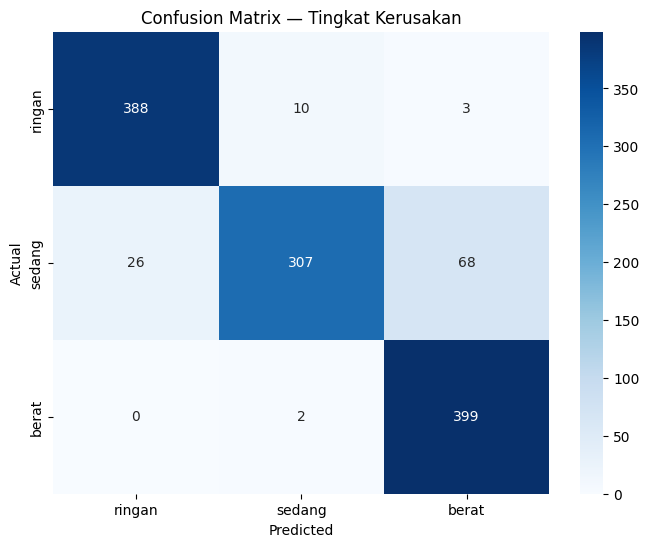

In [26]:
import torch.nn.functional as F

all_class_probs = []
all_severity_preds = []

# Ensure the model is in evaluation mode and on the correct device
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # Move model to device

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        numeric_input  = batch["numeric_input"].to(device)

        class_out, severity_out = model(input_ids, attention_mask, numeric_input)

        # Get class probabilities by applying softmax to logits
        class_probs_batch = F.softmax(class_out, dim=1).cpu().numpy()
        # Get severity predictions and flatten them
        severity_preds_batch = severity_out.squeeze().cpu().numpy()

        all_class_probs.append(class_probs_batch)
        all_severity_preds.append(severity_preds_batch)

class_probs = np.concatenate(all_class_probs, axis=0)
severity_preds = np.concatenate(all_severity_preds, axis=0)

y_pred = np.argmax(class_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
mae      = mean_absolute_error(severity_test, severity_preds)

print("===================================")
print("FINAL EVALUATION")
print("===================================")
print(f"Accuracy : {accuracy:.4f}")
print(f"MAE      : {mae:.6f}")
print("Accuracy Target (>=0.85):", "✅ Achieved" if accuracy >= 0.85 else "❌ Not Achieved")
print("MAE Target      (<=0.10):", "✅ Achieved" if mae <= 0.10     else "❌ Not Achieved")

# FIX: label names sesuai LABEL_MAPPING
target_names = [LABEL_MAPPING[i] for i in sorted(LABEL_MAPPING.keys())]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix — Tingkat Kerusakan")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
# ============================================================
# SAVE MODEL FOR HUGGINGFACE DEPLOYMENT
# ============================================================

import os
import json
import torch
import joblib

# ✅ Ganti path ini sesuai lokasi project kamu
BASE_DIR   = r"C:\LATIHAN_JUPY\Capstone_2026\model"
os.makedirs(BASE_DIR, exist_ok=True)

def save_path(filename):
    return os.path.join(BASE_DIR, filename)

# ============================================================
# 1. Load best model weights
# ============================================================
model.load_state_dict(torch.load("models/best_indobert_model.pt", map_location="cpu"))
model.eval()

# ============================================================
# 2. Save model weights
# ============================================================
torch.save(model.state_dict(), save_path("model_weights.pt"))
print("✅ model_weights.pt saved")

# ============================================================
# 3. Save tokenizer
# ============================================================
tokenizer_dir = os.path.join(BASE_DIR, "tokenizer")
os.makedirs(tokenizer_dir, exist_ok=True)
tokenizer.save_pretrained(tokenizer_dir)
print("✅ tokenizer saved")

# ============================================================
# 4. Save scaler & config.json
# ============================================================
joblib.dump(scaler, save_path("scaler.pkl"))

config = {
    "model_name"      : MODEL_NAME,
    "max_len"         : MAX_LEN,
    "num_classes"     : NUM_CLASSES,
    "label_mapping"   : {str(k): v for k, v in LABEL_MAPPING.items()},
    "numeric_columns" : NUMERIC_COLUMNS,
    "urgency_keywords": URGENCY_KEYWORDS,
    "damage_map"      : {"ringan": 0.2, "sedang": 0.5, "berat": 1.0},
    "bert_hidden_size": 768
}

with open(save_path("config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("✅ config.json saved")

# ============================================================
# 5. Generate model_class.py — otomatis ditulis ke disk
# ============================================================
model_class_code = '''\
import torch
import torch.nn as nn
from transformers import AutoModel


class AttentionLayer(nn.Module):
    def __init__(self, units):
        super().__init__()
        self.W = nn.Linear(units, units)
        self.V = nn.Linear(units, 1)

    def forward(self, features):
        score             = torch.tanh(self.W(features))
        attention_weights = torch.softmax(self.V(score), dim=1)
        context_vector    = attention_weights * features
        return context_vector.sum(dim=1)


class IndoBERTClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.bert = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")
        for param in self.bert.parameters():
            param.requires_grad = False

        bert_hidden = self.bert.config.hidden_size  # 768

        self.attention  = AttentionLayer(bert_hidden)
        self.dropout1   = nn.Dropout(0.4)
        self.dense1     = nn.Linear(bert_hidden, 128)
        self.bn1        = nn.BatchNorm1d(128)
        self.dropout2   = nn.Dropout(0.4)

        self.num_dense1 = nn.Linear(4, 64)
        self.num_drop   = nn.Dropout(0.3)
        self.num_dense2 = nn.Linear(64, 32)

        self.combined1  = nn.Linear(128 + 32, 128)
        self.bn2        = nn.BatchNorm1d(128)
        self.dropout3   = nn.Dropout(0.4)
        self.combined2  = nn.Linear(128, 64)

        self.class_output    = nn.Linear(64, num_classes)
        self.severity_output = nn.Linear(64, 1)

    def forward(self, input_ids, attention_mask, numeric_input):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = self.attention(bert_out.last_hidden_state)
        x = self.dropout1(x)
        x = torch.relu(self.dense1(x))
        x = self.bn1(x)
        x = self.dropout2(x)

        num = torch.relu(self.num_dense1(numeric_input))
        num = self.num_drop(num)
        num = torch.relu(self.num_dense2(num))

        combined = torch.cat([x, num], dim=1)
        combined = torch.relu(self.combined1(combined))
        combined = self.bn2(combined)
        combined = self.dropout3(combined)
        combined = torch.relu(self.combined2(combined))

        class_out    = self.class_output(combined)
        severity_out = torch.sigmoid(self.severity_output(combined))
        return class_out, severity_out
'''

with open(save_path("model_class.py"), "w", encoding="utf-8") as f:
    f.write(model_class_code)
print("✅ model_class.py generated & saved")

# ============================================================
# 6. Generate inference.py — otomatis ditulis ke disk
# ============================================================
inference_code = '''\
import json
import torch
import joblib
import numpy as np
from pathlib import Path
from transformers import AutoTokenizer
from model_class import IndoBERTClassifier

# ── Path relatif terhadap lokasi inference.py ─────────────
BASE = Path(__file__).parent

with open(BASE / "config.json", encoding="utf-8") as f:
    config = json.load(f)

tokenizer = AutoTokenizer.from_pretrained(str(BASE / "tokenizer"))
scaler    = joblib.load(BASE / "scaler.pkl")

device = torch.device("cpu")
model  = IndoBERTClassifier(num_classes=config["num_classes"])
model.load_state_dict(torch.load(BASE / "model_weights.pt", map_location=device))
model.eval()

URGENCY_KEYWORDS = config["urgency_keywords"]
LABEL_MAPPING    = {int(k): v for k, v in config["label_mapping"].items()}


def extract_numeric_features(text: str) -> list:
    text_lower          = text.lower()
    char_length         = len(text)
    word_count          = len(text.split())
    has_urgency_keyword = int(any(kw in text_lower for kw in URGENCY_KEYWORDS))

    urgency_score = 0
    for kw in URGENCY_KEYWORDS:
        if kw in text_lower:
            urgency_score += 10
    if word_count > 20:
        urgency_score += 10
    urgency_score = min(urgency_score, 100)

    return [char_length, word_count, has_urgency_keyword, urgency_score]


def predict(text: str) -> dict:
    encoding = tokenizer(
        text,
        max_length     = config["max_len"],
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt"
    )

    raw_numeric    = extract_numeric_features(text)
    numeric_scaled = scaler.transform([raw_numeric])
    numeric_tensor = torch.tensor(numeric_scaled, dtype=torch.float32)

    with torch.no_grad():
        class_out, severity_out = model(
            input_ids      = encoding["input_ids"],
            attention_mask = encoding["attention_mask"],
            numeric_input  = numeric_tensor
        )

    probs         = torch.softmax(class_out, dim=1).squeeze().tolist()
    predicted_idx = int(torch.argmax(class_out, dim=1).item())
    severity      = float(severity_out.squeeze().item())

    return {
        "label"         : LABEL_MAPPING[predicted_idx],
        "label_id"      : predicted_idx,
        "confidence"    : round(probs[predicted_idx] * 100, 2),
        "severity_score": round(severity, 4),
        "probabilities" : {
            LABEL_MAPPING[i]: round(p * 100, 2)
            for i, p in enumerate(probs)
        }
    }


if __name__ == "__main__":
    test = "Jalan rusak parah dan berlubang besar, sangat membahayakan pengendara!"
    print(predict(test))
'''

with open(save_path("inference.py"), "w", encoding="utf-8") as f:
    f.write(inference_code)
print("✅ inference.py generated & saved")

# ============================================================
# 7. requirements.txt
# ============================================================
requirements = """\
torch>=2.0.0
transformers>=4.35.2
scikit-learn
numpy
joblib
"""

with open(save_path("requirements.txt"), "w") as f:
    f.write(requirements)
print("✅ requirements.txt saved")

# ============================================================
# 8. Summary
# ============================================================
print(f"\n📦 Semua file tersimpan di: {BASE_DIR}\n")
for fname in sorted(os.listdir(BASE_DIR)):
    fpath = os.path.join(BASE_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f"  {fname:<30} {size:.1f} KB")
    else:
        print(f"  {fname}/ (folder)")

✅ model_weights.pt saved
✅ tokenizer saved
✅ config.json saved
✅ model_class.py generated & saved
✅ inference.py generated & saved
✅ requirements.txt saved

📦 Semua file tersimpan di: C:\LATIHAN_JUPY\Capstone_2026\model

  config.json                    0.7 KB
  inference.py                   2.6 KB
  model_class.py                 2.3 KB
  model_weights.pt               489007.2 KB
  requirements.txt               0.1 KB
  scaler.pkl                     1.1 KB
  tokenizer/ (folder)


In [37]:
import shutil

# Zip seluruh folder hf_deployment
shutil.make_archive(
    base_name = "/content/hf_deployment",  # nama file zip output
    format    = "zip",
    root_dir  = "/content",                # parent folder
    base_dir  = "hf_deployment"            # folder yang mau di-zip
)

print("✅ hf_deployment.zip siap didownload")

✅ hf_deployment.zip siap didownload


In [38]:
from google.colab import files
files.download("/content/hf_deployment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## INFERENCE

In [35]:
def get_damage_level(severity_score):
    """Konversi severity score (0-100) ke label tingkat kerusakan."""
    if severity_score < 40:
        return "ringan"
    elif severity_score < 70:
        return "sedang"
    else:
        return "berat"

def predict_damage(text):
    """
    Prediksi tingkat kerusakan infrastruktur menggunakan PyTorch.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    text = str(text)
    urgency_score = calculate_urgency_score(text)

    # Prepare numeric features
    numeric_data = pd.DataFrame([{
        "char_length"        : len(text),
        "word_count"         : len(text.split()),
        "has_urgency_keyword": 1 if urgency_score > 0 else 0,
        "urgency_score"      : urgency_score
    }], columns=NUMERIC_COLUMNS)

    numeric_scaled = scaler.transform(numeric_data).astype("float32")
    numeric_tensor = torch.tensor(numeric_scaled).to(device)

    # Tokenize (using pt for PyTorch)
    tokens = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits, pred_severity = model(
            input_ids      = tokens["input_ids"],
            attention_mask = tokens["attention_mask"],
            numeric_input  = numeric_tensor
        )

    # Process outputs
    pred_class_probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    predicted_class = int(np.argmax(pred_class_probs))
    confidence      = float(np.max(pred_class_probs) * 100)
    severity_score  = round(float(pred_severity.cpu().numpy()[0][0] * 100), 2)

    probabilities = {
        LABEL_MAPPING[i]: round(float(prob * 100), 2)
        for i, prob in enumerate(pred_class_probs)
    }

    return {
        "tingkat_kerusakan": LABEL_MAPPING[predicted_class],
        "severity_score"   : severity_score,
        "confidence"       : round(confidence, 2),
        "probabilities"    : probabilities,
        "deskripsi"        : text
    }

In [36]:
# Test inferensi dengan beberapa contoh laporan
test_cases = [
    "jembatan jalan meruya ambles parah dan menutup akses jalan utama",  # harusnya berat
    "jalan berlubang cukup dalam sekitar 5 cm di depan sekolah",          # harusnya sedang
    "ada celah kecil di aspal jalan dekat pasar",                         # harusnya ringan
    "banjir besar di jalan utama dan air sudah tinggi sangat berbahaya",   # harusnya berat
]

for teks in test_cases:
    # FIX: Pass 'teks' (single string), not 'test_cases' (list)
    result = predict_damage(teks)
    print("===================================")
    print(f"Teks              : {result['deskripsi']}")
    print(f"Tingkat Kerusakan : {result['tingkat_kerusakan']}")
    print(f"Severity Score    : {result['severity_score']}% Ratio")
    print(f"Confidence        : {result['confidence']}% Accuracy")
    print(f"Probabilitas      : {result['probabilities']}")
    print()

Teks              : jembatan jalan meruya ambles parah dan menutup akses jalan utama
Tingkat Kerusakan : berat
Severity Score    : 72.44% Ratio
Confidence        : 91.72% Accuracy
Probabilitas      : {'ringan': 0.79, 'sedang': 7.48, 'berat': 91.72}

Teks              : jalan berlubang cukup dalam sekitar 5 cm di depan sekolah
Tingkat Kerusakan : sedang
Severity Score    : 55.33% Ratio
Confidence        : 51.85% Accuracy
Probabilitas      : {'ringan': 25.0, 'sedang': 51.85, 'berat': 23.16}

Teks              : ada celah kecil di aspal jalan dekat pasar
Tingkat Kerusakan : ringan
Severity Score    : 23.78% Ratio
Confidence        : 93.9% Accuracy
Probabilitas      : {'ringan': 93.9, 'sedang': 4.99, 'berat': 1.12}

Teks              : banjir besar di jalan utama dan air sudah tinggi sangat berbahaya
Tingkat Kerusakan : berat
Severity Score    : 69.92% Ratio
Confidence        : 83.87% Accuracy
Probabilitas      : {'ringan': 2.12, 'sedang': 14.01, 'berat': 83.87}

